In [93]:
import pandas as pd

df_one = pd.DataFrame({
    "Account": ["One", "Two"],
    "Balance": [30, 100]
})

df_two = pd.DataFrame({
    "Account": ["One", "One", "One", "Two", "Two", "Two"],
    "Balance": [30, 20, 10, 100, 40, 110]
})

df_two["Balance"].sum()

310

In [90]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib

df = pd.read_csv("data.csv")
df = df.drop("Unnamed: 0", axis=1)

# Recast Amount column as floats
df.Amount = df.Amount.replace('[\$,]', '', regex=True).astype(float)

# Recast dates as datetime
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = pd.to_datetime(df["Month"])
df["Week"] = pd.to_datetime(df["Week"]) 
df["Date Added"] = pd.to_datetime(df["Date Added"]) 
df["Categorized Date"] = pd.to_datetime(df["Categorized Date"]) 

df["Month"] = df["Month"].dt.strftime('%Y-%m')
df["Week"] = df["Week"].dt.strftime('%U')

print(df.columns.values)
print(df.head())
print(df["Group"].unique())

['Date' 'Description' 'Category' 'Amount' 'Account' 'Account #'
 'Institution' 'Month' 'Week' 'Transaction ID' 'Account ID' 'Check Number'
 'Full Description' 'Date Added' 'Categorized Date' 'Group' 'Tags'
 'Hide From Reports' 'Type']
        Date                                        Description  \
0 2023-11-06  Piedmont N. G. Draft x7001 Personal Travel/vac...   
1 2023-11-06  Citi Autopay Payment x2172 Transportation/leas...   
2 2023-11-05                               Microsoft*pc 1 Month   
3 2023-11-05                                     Zaxby's #x9301   
4 2023-11-05                                     Recreation.gov   

             Category  Amount      Account Account #  \
0            Gas Bill  -30.54        Bills  xxxx9421   
1            Transfer  -30.66        Bills  xxxx9421   
2   Misc Subscription  -10.96  CREDIT CARD  xxxx6526   
3  Restaurants / Bars  -20.00  CREDIT CARD  xxxx6426   
4              Events  -74.00  CREDIT CARD  xxxx6426   

                       In

/tmp/ipykernel_2191/2730613154.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Month"] = pd.to_datetime(df["Month"])
/tmp/ipykernel_2191/2730613154.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Week"] = pd.to_datetime(df["Week"])
/tmp/ipykernel_2191/2730613154.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date Added"] = pd.to_datetime(df["Date Added"])
/tmp/ipykernel_2191/2730613154.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expecte

In [83]:
pivot = pd.pivot_table(
    df,
    values='Amount',
    index='Group',
    columns='Month',
    aggfunc="sum",
    fill_value=0
)

print(pivot)

Month              2023-07   2023-08    2023-09    2023-10  2023-11
Group                                                              
Alternate Income      0.00     32.11    1344.72     417.31     0.00
Bills              -245.65  -3834.36   -3780.35   -2900.44 -2151.74
Donations             0.00   -300.00     -50.00   -1600.00     0.00
Entertainment         0.00   -603.86    -921.50    -604.48  -638.76
Food                  0.00   -797.62   -1011.29   -1158.33   -80.59
Investment            0.00   -500.00    -500.00       0.00     0.00
Maintainence     -10174.00   -347.33    -556.22   -1255.99     0.00
Primary Income     9596.75  11628.03  222937.67   12659.53   197.90
Shopping              0.00  -1445.14   -1739.89   -6005.19  -277.07
Transfer Expense      0.00      0.00       0.00      -0.05     0.00
Transfer Income       0.00      0.00       0.00       0.05     0.00
Transfer Types    -2801.56  -1291.16    7493.66 -127105.18     0.00
Travel                0.00  -2869.95   -2530.94 

/tmp/ipykernel_2191/3947353378.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_df = filtered_df[-df["Category"].isin(ignore_categories)]


Axes(0.125,0.11;0.775x0.77)


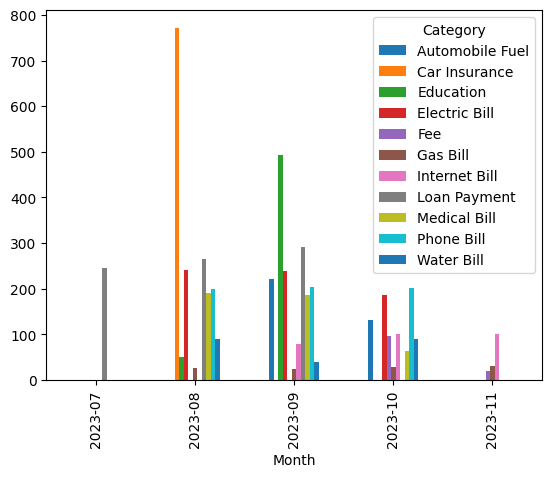

In [84]:
monthly_lookback = 2
group = "Bills"
categories = []
ignore_categories = ["Mortgage Payment"]


filtered_df = df[(df["Group"] == group) & (df["Type"] == "Expense")]
filtered_df.loc[:, 'Amount'] = df['Amount'] * -1


if categories:
    filtered_df = filtered_df[df["Category"].isin(categories)]
if ignore_categories:
    filtered_df = filtered_df[-df["Category"].isin(ignore_categories)]

pivot_filtered = pd.pivot_table(
    filtered_df,
    values='Amount',
    index='Month',
    columns='Category',
    aggfunc="sum",
    fill_value=0
).plot.bar()

print(pivot_filtered)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/ncc/programming/github/nccurry/tiller/venv/lib/python3.11/site-packages/pandas/core/indexes/base.py", line 3790, in get_loc
    >>> non_monotonic_index = pd.Index(list('abcb'))
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "index.pyx", line 152, in pandas._libs.index.IndexEngine.get_loc
  File "index.pyx", line 181, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7080, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7088, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'Date'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/ncc/programming/github/nccurry/tiller/venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3548, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_2191/23661

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/ncc/programming/github/nccurry/tiller/venv/lib/python3.11/site-packages/pandas/core/indexes/base.py", line 3790, in get_loc
    >>> non_monotonic_index = pd.Index(list('abcb'))
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "index.pyx", line 152, in pandas._libs.index.IndexEngine.get_loc
  File "index.pyx", line 181, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7080, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7088, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'Date'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/ncc/programming/github/nccurry/tiller/venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3548, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_2191/30525